In [ ]:
import adaptive_latents as al
from adaptive_latents import NumpyTimedDataSource, Bubblewrap, AnimationManager, default_rwd_parameters, BWRun
from adaptive_latents.transforms.utils import prosvd_data, clip
import matplotlib.pyplot as plt
import numpy as np

In [1]:
# Specify the paths to the files
stim_file_path = '../workspace/datasets/fish/output_020424_ds1/stimmed.txt'
C_file_path = '../workspace/datasets/fish/output_020424_ds1/analysis_proc_C.txt'
photo_file_path = '../workspace/datasets/fish/output_020424_ds1/photostims.npy'

# Load the files
stim = np.loadtxt(stim_file_path) 
"""1st entry: frame number,
2nd entry: ignore,
3rd entry: angle of motion L,
4th entry: angle of motion R,
5th entry: timestamp,"""
C = np.loadtxt(C_file_path)#
"""Calcium imaging. 
1st entry is neuron ID,
2nd is time (frame)"""
photostim = np.load(photo_file_path)
"""1st entry: frame number,
2nd entry: counter of stims,
3rd entry: neuron ID,
4th entry: position X of neuron,
5th entry: position Y of neuron,"""

# extra note: Fs= 2.3 Hz

'1st entry: frame number,\n2nd entry: counter of stims,\n3rd entry: neuron ID,\n4th entry: position X of neuron,\n5th entry: position Y of neuron,'

In [2]:
stim.shape, C.shape, photostim.shape

((31, 5), (556, 5405), (126, 5))

## Plot positions

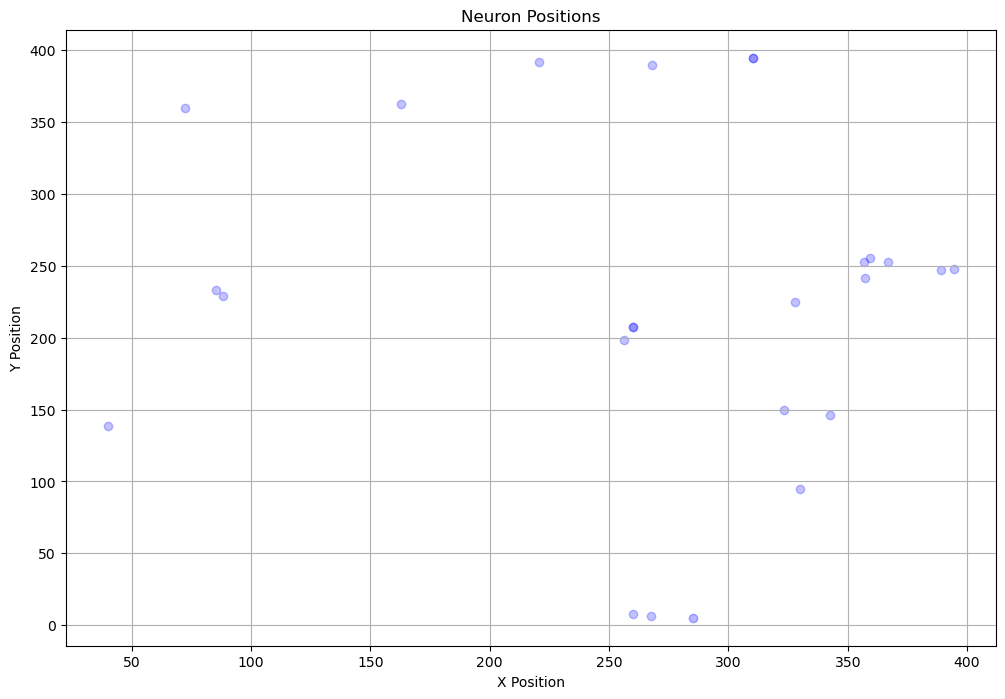

In [13]:
# Extract x and y positions
x_positions = photostim[:, 3]
y_positions = photostim[:, 4]

# Plot the positions
plt.figure(figsize=(12, 8))
plt.scatter(x_positions, y_positions, c='blue', marker='o', alpha=0.05)

# Plot the texts far from the dots and connect them with lines
for i, (x, y) in enumerate(zip(x_positions, y_positions)):
    label_x = x + 0.5  # Adjust the offset for better visualization
    label_y = y + 0.5  # Adjust the offset for better visualization
    plt.text(label_x, label_y, f'Neuron {i+1}', fontsize=12, ha='center', color='red')
    plt.plot([x, label_x], [y, label_y], 'k-', lw=0.5)  # Draw a line connecting the dot and the label

plt.title('Neuron Positions')
plt.xlabel('X Position')
plt.ylabel('Y Position')
plt.grid(True)
plt.show()

In [14]:
# Find duplicate positions
positions = photostim[:, 3:5]

duplicates = {}
for i, pos1 in enumerate(positions):
    for j, pos2 in enumerate(positions):
        if i != j and np.array_equal(pos1, pos2):
            if tuple(pos1) not in duplicates:
                duplicates[tuple(pos1)] = [i+1]
            duplicates[tuple(pos1)].append(j+1)

# Filter out unique duplicates
unique_duplicates = {k: list(set(v)) for k, v in duplicates.items() if len(set(v)) > 1}

# Print the results
print("Neurons with identical (X, Y) positions:")
for pos, neurons in unique_duplicates.items():
    print(f"Position {pos} is shared by neurons: {neurons}")

Neurons with identical (X, Y) positions:
Position (394.3532409667969, 247.73289489746094) is shared by neurons: [1, 2, 3, 4, 5]
Position (259.9203796386719, 207.7105255126953) is shared by neurons: [6, 7, 8, 9, 10, 106, 107, 108, 109, 110]
Position (285.2468566894531, 5.215221881866455) is shared by neurons: [11, 12, 13, 14, 15, 126]
Position (88.20176696777344, 228.8241424560547) is shared by neurons: [16, 17, 18, 19, 20]
Position (40.095977783203125, 138.6578369140625) is shared by neurons: [21, 22, 23, 24, 25]
Position (267.881103515625, 390.0087890625) is shared by neurons: [26, 27, 28, 29, 30]
Position (162.9873046875, 362.4356689453125) is shared by neurons: [32, 33, 34, 35, 31]
Position (357.2541809082031, 241.5909881591797) is shared by neurons: [36, 37, 38, 39, 40]
Position (220.73948669433594, 392.0863037109375) is shared by neurons: [41, 42, 43, 44, 45]
Position (72.17987060546875, 359.76983642578125) is shared by neurons: [46, 47, 48, 49, 50]
Position (256.02630615234375, 1

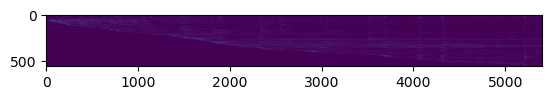

In [6]:
plt.imshow(C)

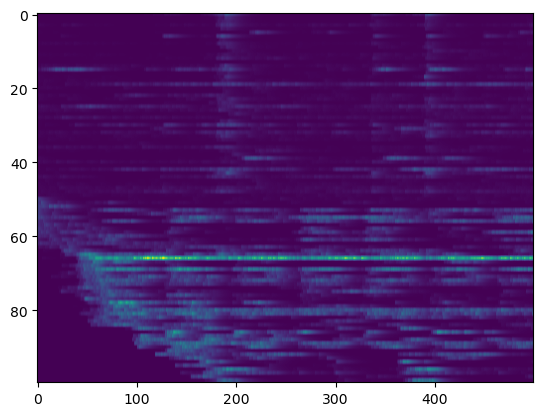

In [7]:
#defining and displaying a smaller subset of C
C_small = C[0:100, :500]
plt.imshow(C_small, aspect='auto')

In [8]:
#max and min of the stim times
stim[:,0].max(), stim[:,0].min()

(1062.0, 56.0)

In [9]:
#max and min of the photostim times
photostim[:,0].min(), photostim[:,0].max()

(1114.0, 5391.0)

This last two results indicate that the fish was first shown visual stimulations and then stimulated with optogenetics

## Looking at effect of stim and photostim in spike trains

In [1]:
#first stim
#plotting the first 10 entries of the first column in stim as a red line over our small C

plt.imshow(C_small, aspect='auto')

#first_stims = stim[:5,0]

# Plot the red lines over the imshow graph
for i in range(10):
    first_stims = stim[i,0]
    plt.axvline(x=first_stims, color='red', linestyle='-')

# Display the plot
plt.colorbar()
plt.show()



NameError: name 'plt' is not defined

## Now let's move to the time when the experiment transitioned from sim to photo stim

([<matplotlib.axis.XTick at 0x7cd3eb8291f0>,
 [Text(0, 0, '1000'),
  Text(100, 0, '1100'),
  Text(200, 0, '1200'),
  Text(300, 0, '1300'),
  Text(400, 0, '1400')])

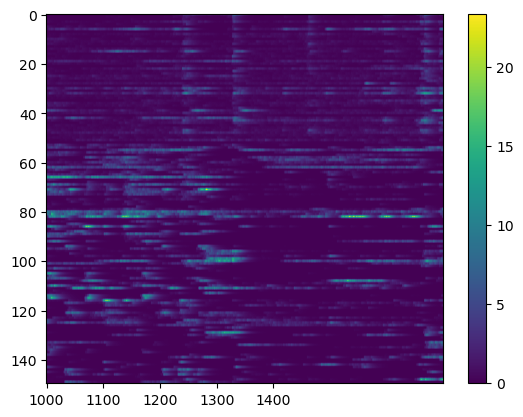

In [11]:
#We know the transition is arround 1000
C_transition = C[:150, 800:1500]
plt.imshow(C_transition, aspect='auto')
plt.colorbar()
plt.xticks(ticks=np.arange(0, 500, step=100), labels=np.arange(1000, 1500, step=100))#changing the x axis to show the frame number

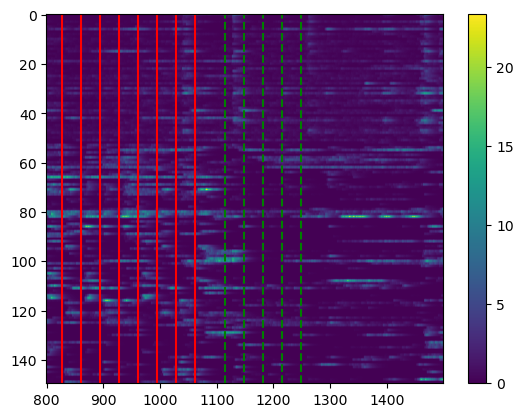

In [12]:
#Now plot photostim and stim on top of this

plt.imshow(C_transition, aspect='auto')
plt.colorbar()
plt.xticks(ticks=np.arange(0, 700, step=100), labels=np.arange(800, 1500, step=100))

# Extract the last ten entries of the first column
stims = stim[-10:, 0]

# Plot the red lines over the imshow graph
for s in stims:
    # Convert the stim value to the appropriate x-coordinate in the range 0-700
    if 800 <= s < 1500:
        plt.axvline(x=s - 800, color='red', linestyle='-')

#Same logic fr first 10 photostims
photostims = photostim[:5, 0]

for p in photostims:
    if 800 <= p < 1500:
        plt.axvline(x=p - 800, color='green', linestyle='--')



# Display the plot
plt.show()


In [13]:
#first 10 photostim frames and the neuron ID
photostim[:10,0], photostim[:10,2]

(array([1114., 1148., 1182., 1216., 1249., 1284., 1318., 1352., 1386.,
        1418.]),
 array([109., 109., 109., 109., 109.,  98.,  98.,  98.,  98.,  98.]))

Note that the photostim occurs every 34 frames

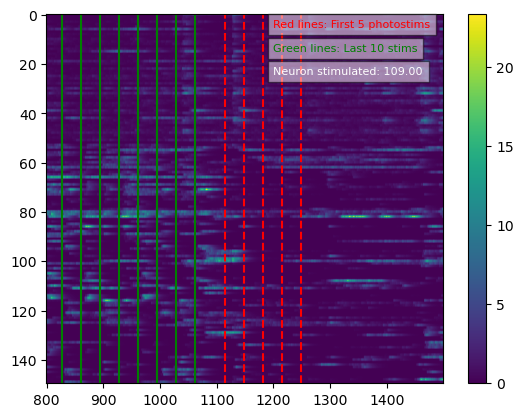

In [14]:
# refining the plot
plt.imshow(C_transition, aspect='auto')
plt.colorbar()
plt.xticks(ticks=np.arange(0, 700, step=100), labels=np.arange(800, 1500, step=100))

# Extract the last ten entries of the first column
stims = stim[-10:, 0]

# Plot the red lines over the imshow graph
for s in stims:
    # Convert the stim value to the appropriate x-coordinate in the range 0-700
    if 800 <= s < 1500:
        plt.axvline(x=s - 800, color='green', linestyle='-')

#Same logic fr first 10 photostims
photostims = photostim[:5, 0]

for p in photostims:
    if 800 <= p < 1500:
        plt.axvline(x=p - 800, color='red', linestyle='--')


# Add notes to the plot
plt.text(400, 5, 'Red lines: First 5 photostims', color='red', fontsize=8,
         bbox=dict(facecolor='white', alpha=0.5))
plt.text(400, 15, 'Green lines: Last 10 stims', color='green', fontsize=8,
         bbox=dict(facecolor='white', alpha=0.5))


# Add a blue indicator in the y axis for the number present in photostim[:1, 2]
y_value = photostim[0, 2]
#plt.axhline(y=y_value, color='white', linestyle='--')
plt.text(400, 25, f'Neuron stimulated: {y_value:.2f}', color='white', fontsize= 8, verticalalignment='bottom',
         bbox=dict(facecolor='white', alpha=0.5))

# Display the plot
plt.show()

## Let's see how the neuron 109 behaves before and after photostim

Text(0.5, 1.0, 'Neuron 109 with first 5 photostims')

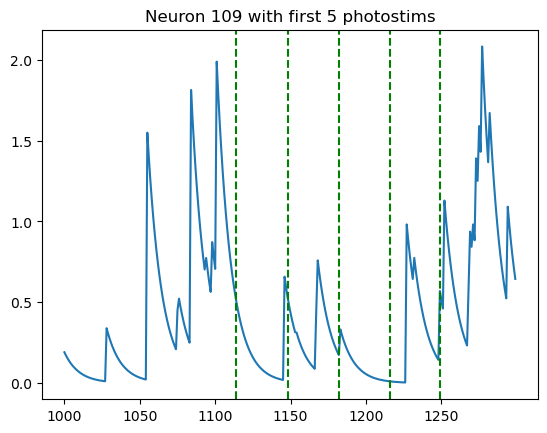

In [15]:
#plotting neruon 109 from frame 1000 to 1147
#also add a red line at the first photostim and adjust x axis labels to match the frame number
neuron_109 = C[109, 1000:1300]
plt.plot(neuron_109)
photostims = photostim[:5, 0]

for p in photostims:
    if 800 <= p < 1500:
        plt.axvline(x=p - 1000, color='green', linestyle='--')

plt.xticks(ticks=np.arange(0, 300, step=50), labels=np.arange(1000, 1300, step=50))
plt.title('Neuron 109 with first 5 photostims')

## Trajectory in low dimension subspace. Using PCA

In [16]:
#Create another C matrix but just looking at stimulations in neuron 109
C_transition1=C[:150, 800:1280]
C_transition1.shape

(150, 480)

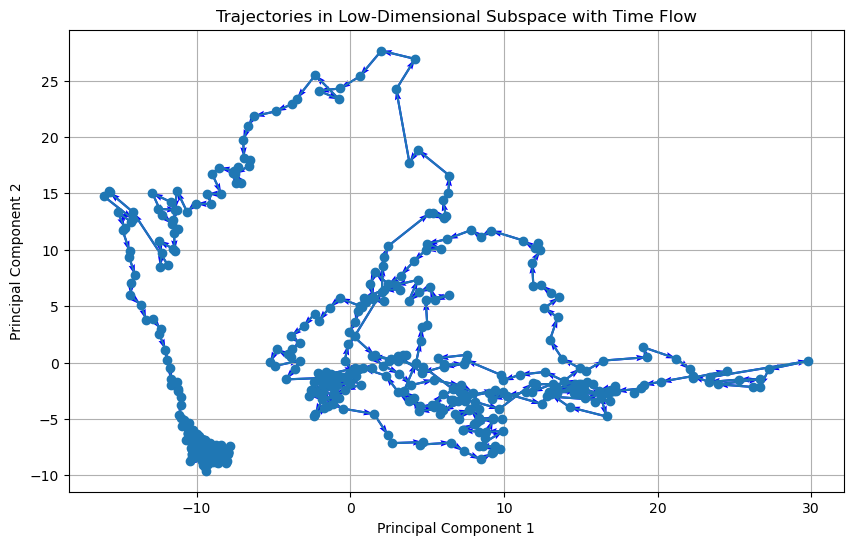

In [17]:
#perform a PCA to c_transition and see the trajectories of the first 2 components
from sklearn.decomposition import PCA

# Perform PCA to reduce dimensions
pca = PCA(n_components=2)
principal_components = pca.fit_transform(C_transition1.T)

# Extract the first two principal components
pc1 = principal_components[:, 0]
pc2 = principal_components[:, 1]

# Plot the trajectories of the first two principal components
plt.figure(figsize=(10, 6))
plt.plot(pc1, pc2, marker='o')

# Add arrows to indicate the flow of time using quiver
plt.quiver(pc1[:-1], pc2[:-1], np.diff(pc1), np.diff(pc2), scale_units='xy', angles='xy', scale=1, color='blue')

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('Trajectories in Low-Dimensional Subspace with Time Flow')
plt.grid(True)
plt.show()


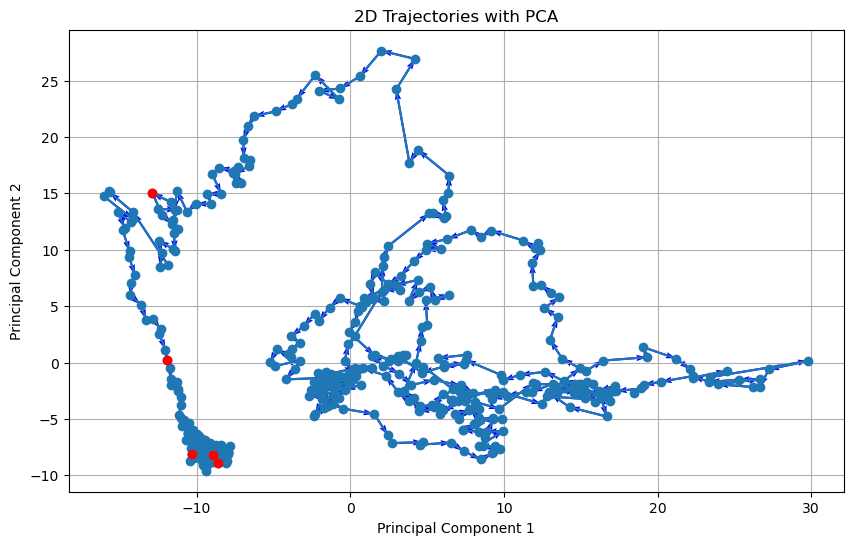

In [18]:
#now add the points where the photostimulations happened
# Extract the first two principal components (PC1 and PC2)
pc1 = principal_components[:, 0]  # First principal component
pc2 = principal_components[:, 1]  # Second principal component

# Extract the first five values of the first column of photostim
photostim_indices = np.clip(photostim[:5, 0].astype(int) - 800, 0, 699)  # Ensure indices are within bounds

# Plot the trajectories of the first two principal components
plt.figure(figsize=(10, 6))
plt.plot(pc1, pc2, marker='o')

# Add arrows to indicate the flow of time using quiver
plt.quiver(pc1[:-1], pc2[:-1], np.diff(pc1), np.diff(pc2), scale_units='xy', angles='xy', scale=1, color='blue')

# Add red dots at the time steps corresponding to the values in photostim[:5, 0]
plt.scatter(pc1[photostim_indices], pc2[photostim_indices], color='red', zorder=5)

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('2D Trajectories with PCA')
plt.grid(True)
plt.show()

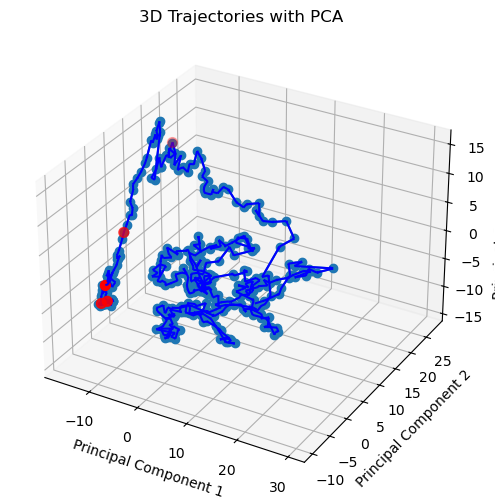

In [19]:
#now in 3d
# Perform PCA to reduce dimensions
pca = PCA(n_components=3)
principal_components = pca.fit_transform(C_transition1.T)

# Extract the first two principal components
pc1 = principal_components[:, 0]
pc2 = principal_components[:, 1]
pc3 = principal_components[:, 2]  # Third principal component

# Extract the first five values of the first column of photostim
photostim_indices = np.clip(photostim[:5, 0].astype(int) - 800, 0, 699)  # Ensure indices are within bounds

# Create a 3D plot
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111, projection='3d')

# Plot the trajectories of the first three principal components
ax.plot(pc1, pc2, pc3, marker='o')

# Add arrows to indicate the flow of time using quiver
for i in range(len(pc1) - 1):
    ax.quiver(pc1[i], pc2[i], pc3[i], pc1[i+1] - pc1[i], pc2[i+1] - pc2[i], pc3[i+1] - pc3[i], color='blue', arrow_length_ratio=0.1)

# Add red dots at the time steps corresponding to the values in photostim[:5, 0]
ax.scatter(pc1[photostim_indices], pc2[photostim_indices], pc3[photostim_indices], color='red', s=50, zorder=5)

ax.set_xlabel('Principal Component 1')
ax.set_ylabel('Principal Component 2')
ax.set_zlabel('Principal Component 3')
ax.set_title('3D Trajectories with PCA')
plt.show()

## Low dimension trajectory with proSVD

In [3]:
from adaptive_latents import Bubblewrap, BWRun, NumpyTimedDataSource, default_rwd_parameters
from adaptive_latents.transforms.utils import prosvd_data, clip
import adaptive_latents.plotting_functions as pf

In [21]:
# this line applies proSVD all at once; it uses the streaming algorithm, but looks like it's offline
twoDim_C = prosvd_data(C_transition1.T,2, 20, centering=True)

100%|██████████| 460/460 [00:00<00:00, 18545.31it/s]


In [33]:
twoDim_C.shape

(460, 2)

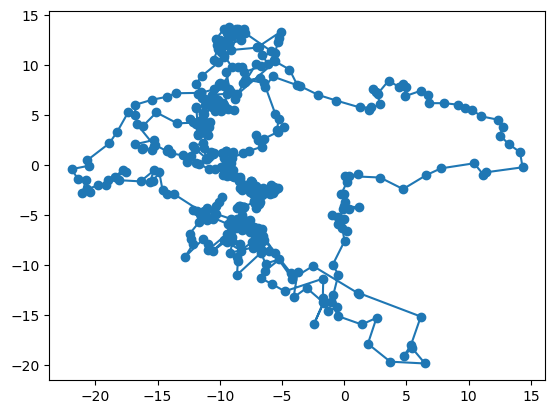

In [22]:
plt.plot(twoDim_C[:,0], twoDim_C[:,1], marker='o')
# Extract the first five values of the first column of photostim
photostim_indices = np.clip(photostim[:5, 0].astype(int) - 800, 0, len(twoDim_C) - 1)  # Ensure indices are within bounds


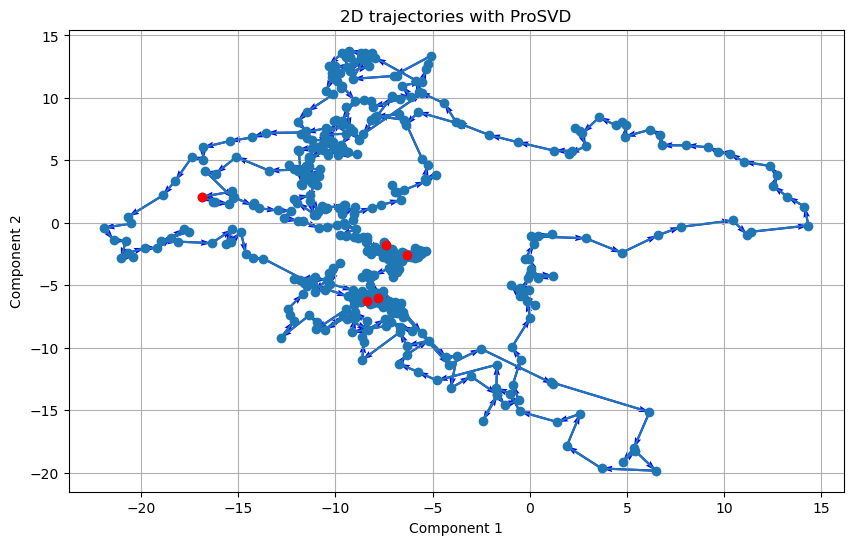

In [23]:
# Plot the trajectories of the processed data
plt.figure(figsize=(10, 6))
plt.plot(twoDim_C[:, 0], twoDim_C[:, 1], marker='o')

# Add arrows to indicate the flow of time using quiver
plt.quiver(twoDim_C[:-1, 0], twoDim_C[:-1, 1], np.diff(twoDim_C[:, 0]), np.diff(twoDim_C[:, 1]), 
           scale_units='xy', angles='xy', scale=1, color='blue')

# Add red dots at the time steps corresponding to the values in photostim[:5, 0]
plt.scatter(twoDim_C[photostim_indices, 0], twoDim_C[photostim_indices, 1], color='red', zorder=5)

plt.xlabel('Component 1')
plt.ylabel('Component 2')
plt.title('2D trajectories with ProSVD')
plt.grid(True)
plt.show()

100%|██████████| 460/460 [00:00<00:00, 17118.09it/s]


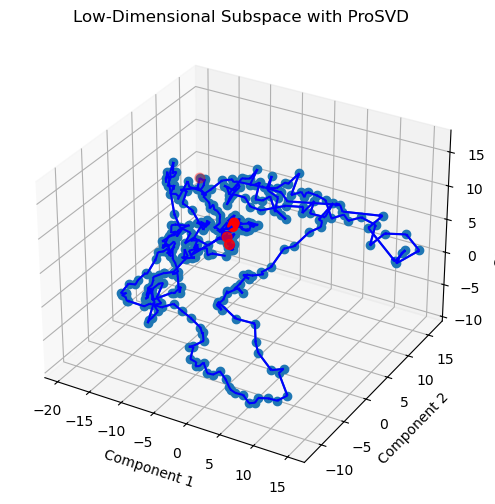

In [24]:
#now 3 dimensions
threeDim_C = prosvd_data(C_transition1.T,3, 20, centering=True)
photostim_indices = np.clip(photostim[:5, 0].astype(int) - 800, 0, len(threeDim_C) - 1)

# Create a 3D plot
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111, projection='3d')

# Plot the trajectories of the processed data
ax.plot(threeDim_C[:, 0], threeDim_C[:, 1], threeDim_C[:, 2], marker='o')

# Add arrows to indicate the flow of time using quiver
for i in range(len(threeDim_C) - 1):
    ax.quiver(threeDim_C[i, 0], threeDim_C[i, 1], threeDim_C[i, 2],
              threeDim_C[i+1, 0] - threeDim_C[i, 0], threeDim_C[i+1, 1] - threeDim_C[i, 1], threeDim_C[i+1, 2] - threeDim_C[i, 2],
              color='blue', arrow_length_ratio=0.1)

# Add red dots at the time steps corresponding to the values in photostim[:5, 0]
ax.scatter(threeDim_C[photostim_indices, 0], threeDim_C[photostim_indices, 1], threeDim_C[photostim_indices, 2], color='red', s=50, zorder=5)

ax.set_xlabel('Component 1')
ax.set_ylabel('Component 2')
ax.set_zlabel('Component 3')
ax.set_title('Low-Dimensional Subspace with ProSVD')
plt.show()

## Graphing stim vs photostim with PCA 

Same amount of neurons (150) because not all of them are online beginning to end 

In [25]:
C_stims=C[:150, 1147-500:1147] #uing just when there was visual stmuli (500 frames)
C_photostims=C[:150, 1114:1114 + 500] #using just when there was photostimuli(500 frames)

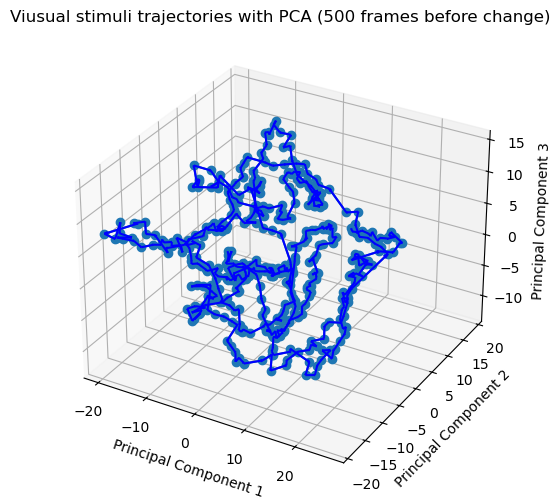

In [26]:
#now in 3d
# Perform PCA to reduce dimensions
pca_visual_stim = PCA(n_components=3)
principal_components = pca_visual_stim.fit_transform(C_stims.T)

# Extract the first two principal components
pc1 = principal_components[:, 0]
pc2 = principal_components[:, 1]
pc3 = principal_components[:, 2]  # Third principal component

# Extract the first five values of the first column of photostim
#photostim_indices = np.clip(photostim[:5, 0].astype(int) - 800, 0, 699)  # Ensure indices are within bounds

# Create a 3D plot
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111, projection='3d')

# Plot the trajectories of the first three principal components
ax.plot(pc1, pc2, pc3, marker='o')

# Add arrows to indicate the flow of time using quiver
for i in range(len(pc1) - 1):
    ax.quiver(pc1[i], pc2[i], pc3[i], pc1[i+1] - pc1[i], pc2[i+1] - pc2[i], pc3[i+1] - pc3[i], color='blue', arrow_length_ratio=0.1)

# Add red dots at the time steps corresponding to the values in photostim[:5, 0]
#ax.scatter(pc1[photostim_indices], pc2[photostim_indices], pc3[photostim_indices], color='red', s=50, zorder=5)

ax.set_xlabel('Principal Component 1')
ax.set_ylabel('Principal Component 2')
ax.set_zlabel('Principal Component 3')
ax.set_title('Viusual stimuli trajectories with PCA (500 frames before change)')
plt.show()

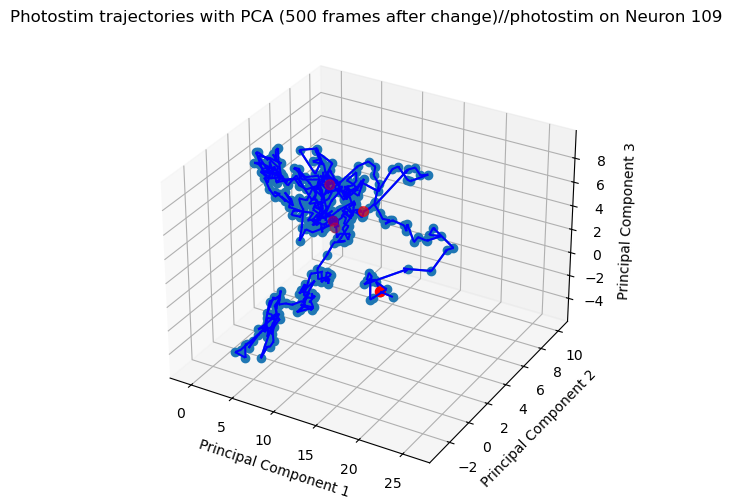

In [27]:
#now use the same principal components used for viual stimuli in photostimuli
principal_components_photo = pca_visual_stim.transform(C_photostims.T) #use transform instead of fit_transform

# Extract the first two principal components
pc1 = principal_components_photo[:, 0]
pc2 = principal_components_photo[:, 1]
pc3 = principal_components_photo[:, 2]  

# Extract the first five values of the first column of photostim
photostim_indices = np.clip(photostim[:5, 0].astype(int) - 1113, 0, 499)  # Ensure indices are within bounds

# Create a 3D plot
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111, projection='3d')

# Plot the trajectories of the first three principal components
ax.plot(pc1, pc2, pc3, marker='o')

# Add arrows to indicate the flow of time using quiver
for i in range(len(pc1) - 1):
    ax.quiver(pc1[i], pc2[i], pc3[i], pc1[i+1] - pc1[i], pc2[i+1] - pc2[i], pc3[i+1] - pc3[i], color='blue', arrow_length_ratio=0.1)

# Add red dots at the time steps corresponding to the values in photostim[:5, 0]
ax.scatter(pc1[photostim_indices], pc2[photostim_indices], pc3[photostim_indices], color='red', s=50, zorder=5)

ax.set_xlabel('Principal Component 1')
ax.set_ylabel('Principal Component 2')
ax.set_zlabel('Principal Component 3')
ax.set_title('Photostim trajectories with PCA (500 frames after change)//photostim on Neuron 109')
plt.show()

In [28]:
#just to check that indices make sense:
photostim[:5, 0], photostim_indices

(array([1114., 1148., 1182., 1216., 1249.]), array([  1,  35,  69, 103, 136]))

### To make things easier we can define a function that plots 
### the frame of photostimulation for the neuron of interest

In [29]:
def plot_photostim_k(k, pca_components):
    # Adjust what neuron to display (170 because 34 frames per photostim and 5 photostims per neuron)
    C_photostims = C[:150, 1114 + (170 * (k-1)):1114 + (170 * k)]
    
    # Use the same principal components used for visual stimuli in photostimuli
    principal_components_photo = pca_components.transform(C_photostims.T)  # use transform instead of fit_transform

    # Extract the first three principal components
    pc1 = principal_components_photo[:, 0]
    pc2 = principal_components_photo[:, 1]
    pc3 = principal_components_photo[:, 2]  

    # Extract the corresponding five values of the first column of photostim corresponding to the neuron of interest k
    photostim_indices = np.clip(photostim[(k*5)-5:k*5, 0].astype(int) - (1114 + (170 * (k-1))), 0, 170 ) # Ensure indices are within bounds

    # Create a 3D plot
    fig = plt.figure(figsize=(10, 6))
    ax = fig.add_subplot(111, projection='3d')

    # Plot the trajectories of the first three principal components
    ax.plot(pc1, pc2, pc3, marker='o')

    # Add arrows to indicate the flow of time using quiver
    for i in range(len(pc1) - 1):
        ax.quiver(pc1[i], pc2[i], pc3[i], pc1[i+1] - pc1[i], pc2[i+1] - pc2[i], pc3[i+1] - pc3[i], color='blue', arrow_length_ratio=0.1)

    # Add red dots at the time steps corresponding to the values in photostim[:5, 0] and enumerate them
    for idx, photostim_index in enumerate(photostim_indices):
        ax.scatter(pc1[photostim_index], pc2[photostim_index], pc3[photostim_index], color='red', s=50, zorder=5)
        ax.text(pc1[photostim_index], pc2[photostim_index], pc3[photostim_index], str(idx+1), color='black', fontsize=12)

    ax.set_xlabel('Principal Component 1')
    ax.set_ylabel('Principal Component 2')
    ax.set_zlabel('Principal Component 3')
    ax.set_title(f'Photostim trajectories with PCA // Neuron {photostim[(k*5)-1, 2]}')
    plt.show()

In [30]:
#To check if the red dots make sense:
k=3
photostim_indices = np.clip(photostim[(k*5)-5:k*5, 0].astype(int) - (1114 + (170 * (k-1))), 0, 170 )
photostim_indices, photostim[(k*5)-5:k*5, 0]

(array([  0,  34,  68, 101, 136]), array([1454., 1488., 1522., 1555., 1590.]))

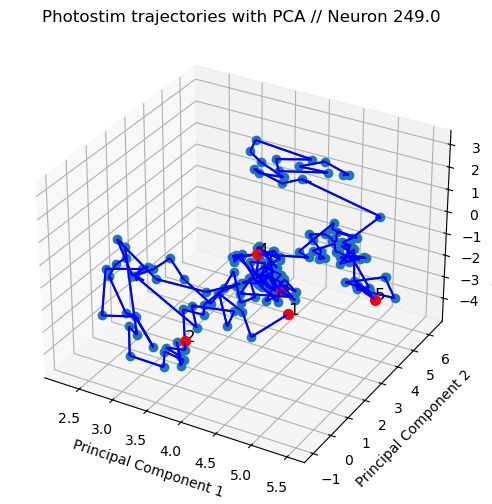

In [31]:
plot_photostim_k(4, pca_visual_stim)

# Create a dataframe to organize data better to verify plots

In [1]:
import pandas as pd

# Create DataFrame for stim
stim_columns = ['frame_number', 'ignore', 'angle_of_motion_L', 'angle_of_motion_R', 'timestamp']
stim_df = pd.DataFrame(stim, columns=stim_columns)

# Create DataFrame for C, where each column after the first represents a neuron
neuron_ids = [f'neuron_{i}' for i in range(C.shape[0])]
time_points = [f'frame_{i}' for i in range(C.shape[1])]
C_df = pd.DataFrame(C.T, columns=neuron_ids, index=time_points)

# Create DataFrame for photostim
photostim_columns = ['frame_number', 'stim_counter', 'neuron_ID', 'position_X', 'position_Y']
photostim_df = pd.DataFrame(photostim, columns=photostim_columns)

# Set the option to display more rows
pd.set_option('display.max_rows', 100)  # Adjust the number to the desired number of rows

# Display the DataFrames
# Display different ranges of rows
#print("Photostim DataFrame - Rows 0 to 9:\n", photostim_df.iloc[0:10])
#print("\nPhotostim DataFrame - Rows 50 to 59:\n", photostim_df.iloc[50:60])
print("\nPhotostim DataFrame - Rows 100 to 109:\n", photostim_df.iloc[:25])


NameError: name 'stim' is not defined

In [2]:
def plot_photostim_prosvd(k, prosvd_data, C, photostim):
    # Adjust what neuron to display (170 because 34 frames per photostim and 5 photostims per neuron)
    C_photostims = C[:, 1114 + (170 * (k-1)):1114 + (170 * k)]
    
    # Use proSVD on the photostim data
    threeDim_C = prosvd_data(C_photostims.T, 3, 20, centering=True)
    
    # Extract the corresponding five values of the first column of photostim corresponding to the neuron of interest k
    photostim_indices = np.clip(photostim[(k*5)-5:k*5, 0].astype(int) - (1114 + (170 * (k-1))), 0, len(threeDim_C) - 1)  # Ensure indices are within bounds
    
    # Create a 3D plot
    fig = plt.figure(figsize=(10, 6))
    ax = fig.add_subplot(111, projection='3d')
    
    # Plot the trajectories of the processed data
    ax.plot(threeDim_C[:, 0], threeDim_C[:, 1], threeDim_C[:, 2], marker='o')
    
    # Add arrows to indicate the flow of time using quiver
    for i in range(len(threeDim_C) - 1):
        ax.quiver(threeDim_C[i, 0], threeDim_C[i, 1], threeDim_C[i, 2],
                  threeDim_C[i+1, 0] - threeDim_C[i, 0], threeDim_C[i+1, 1] - threeDim_C[i, 1], threeDim_C[i+1, 2] - threeDim_C[i, 2],
                  color='blue', arrow_length_ratio=0.1)
    
    # Add red dots at the time steps corresponding to the values in photostim[:5, 0]
    for idx, photostim_index in enumerate(photostim_indices):
        ax.scatter(threeDim_C[photostim_index, 0], threeDim_C[photostim_index, 1], threeDim_C[photostim_index, 2], color='red', s=50, zorder=5)
        ax.text(threeDim_C[photostim_index, 0], threeDim_C[photostim_index, 1], threeDim_C[photostim_index, 2], str(idx+1), color='black', fontsize=12)
    
    ax.set_xlabel('Component 1')
    ax.set_ylabel('Component 2')
    ax.set_zlabel('Component 3')
    ax.set_title(f'Photostim trajectories with proSVD // Neuron {photostim[(k*5)-1, 2]}')
    plt.show()

100%|██████████| 150/150 [00:00<00:00, 2883.77it/s]


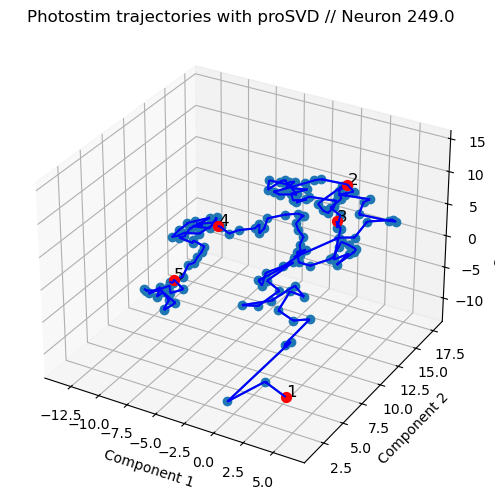

In [9]:
plot_photostim_prosvd(4, prosvd_data, C, photostim)